# CASE: UAV sensors — vegetation indices from real Altum & REMX data

**Extends:** [case-uav.md](https://pangeos-cost.github.io/uq-training/case-studies/case-uav/) and
[`case_uav-Ex1_AltumREMX_MethodComparison.ipynb`](case_uav-Ex1_AltumREMX_MethodComparison.ipynb),
using real 2025 Norway field-campaign data (Plot 103) analysed under sub-optimal, variable-cloud
illumination conditions.

**Reference:** Werfeli, Mihai *et al.* (in review), *"Uncertainty propagation and intercomparison
of multi-sensor measurements of vegetation stress in sub-optimal conditions."*

## What this notebook is about, in plain language

This notebook computes vegetation indices (NDVI, OSAVI, EVI, and — for REMX only — PRI) from the
real Altum and REMX reflectance built in
[`case_uav-Ex1_AltumREMX_MethodComparison.ipynb`](case_uav-Ex1_AltumREMX_MethodComparison.ipynb),
for both the grey-panel and white-panel calibration methods, and checks every value against the
official campaign result.

Altum's indices match the official values; REMX's are close but not exact.

!!! tip "Not just for this dataset"
    The same index formulas and validation approach apply to any UAV multispectral camera with
    similar band coverage — not only Altum and REMX.

**Prerequisites:** [`case_uav-Ex1_AltumREMX_MethodComparison.ipynb`](case_uav-Ex1_AltumREMX_MethodComparison.ipynb).

# Learning objectives

**After following this notebook you will be able to ...**
- Compute vegetation indices from real UAV reflectance, respecting each camera's actual band
  availability
- Validate computed index values against an official reference, band by band
- Recognise that "the same pipeline, two cameras" does not guarantee identical validation
  outcomes — and treat that as a finding, not a bug to explain away

# TOC

1. [Imports](#1)
2. [Loading real reflectance and computing indices](#2)
3. [Checking against the official campaign result](#3)
4. [A sign convention worth noticing](#4)

# 1
## Imports

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# 2
## Loading real reflectance and computing indices

[back to TOC](#TOC)

Altum lacks a band near 531 nm, so PRI is not computed for it (see
[case-uav.md](https://pangeos-cost.github.io/uq-training/case-studies/case-uav/#vegetation-indices-with-a-band-availability-caveat)).
MTCI needs bands near 681, 709, and 754 nm — neither camera has that combination (Altum's closest
red-edge band is a single one at 717 nm; REMX has bands at 705/717/740 nm but nothing near
681 nm), so MTCI is not computed for either camera, matching the official campaign workbook,
where the MTCI columns for both Altum and REMX are empty. Both cameras support NDVI, OSAVI, and
EVI.

In [2]:
data_dir = Path('../data/case-uav-plot103')

altum_gp = pd.read_csv(data_dir / 'altum_greypanel.csv').set_index('wvl')['R']
altum_wp = pd.read_csv(data_dir / 'altum_whitepanel.csv').set_index('wvl')['R']
remx_gp  = pd.read_csv(data_dir / 'remx_greypanel.csv').set_index('wvl')['R']
remx_wp  = pd.read_csv(data_dir / 'remx_whitepanel.csv').set_index('wvl')['R']

def NDVI_fun(R780, R670): return (R780 - R670) / (R780 + R670)
def OSAVI_fun(R780, R670): return 1.16 * (R780 - R670) / (R780 + R670 + 0.16)
def EVI_fun(R780, R670, R480): return 2.5 * (R780 - R670) / (R780 + 6*R670 - 7.5*R480 + 1)
def PRI_fun(R570, R531): return (R570 - R531) / (R570 + R531)

rows = []
for name, R in [('Altum GP', altum_gp), ('Altum WP', altum_wp), ('REMX GP', remx_gp), ('REMX WP', remx_wp)]:
    row = {
        'product': name,
        'NDVI': NDVI_fun(R[842], R[668]),
        'OSAVI': OSAVI_fun(R[842], R[668]),
        'EVI': EVI_fun(R[842], R[668], R[475]),
    }
    if 'REMX' in name:  # only REMX has the ~531 nm band PRI needs
        row['PRI'] = PRI_fun(R[560], R[531])
    rows.append(row)

mine_df = pd.DataFrame(rows).set_index('product')
mine_df.round(4)

,NDVI,OSAVI,EVI,PRI
product,,,,
Altum GP,0.8865,0.7765,0.7512,NaN
Altum WP,0.8673,0.7130,0.6126,NaN
REMX GP,0.8450,0.7414,0.7303,0.0543
REMX WP,0.8400,0.7030,0.6221,0.0064


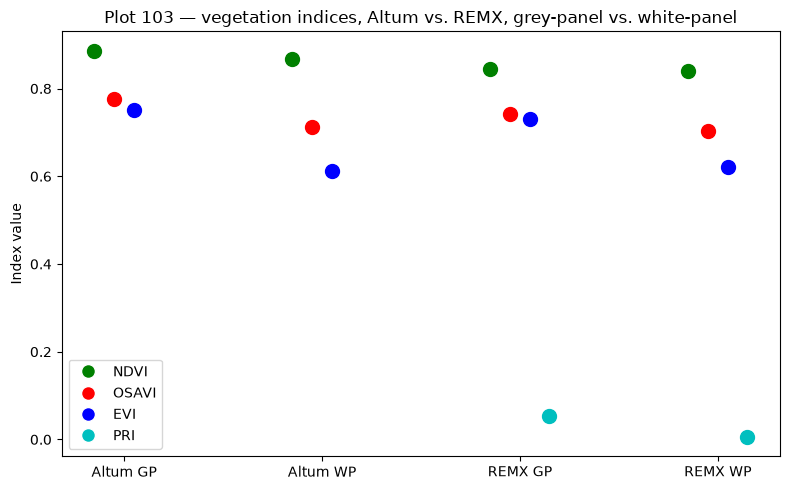

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
index_colors = {'NDVI': 'g', 'OSAVI': 'r', 'EVI': 'b', 'PRI': 'c'}
offsets = {'NDVI': -0.15, 'OSAVI': -0.05, 'EVI': 0.05, 'PRI': 0.15}
for x, product in enumerate(mine_df.index):
    for idx_name, color in index_colors.items():
        val = mine_df.loc[product, idx_name]
        if pd.notna(val):
            ax.plot(x + offsets[idx_name], val, 'o', color=color, markersize=10)
ax.set_xticks(range(len(mine_df.index))); ax.set_xticklabels(mine_df.index)
ax.set_ylabel('Index value')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=n)
           for n, c in index_colors.items()]
ax.legend(handles=handles)
ax.set_title('Plot 103 — vegetation indices, Altum vs. REMX, grey-panel vs. white-panel')
plt.tight_layout()
plt.show()

# 3
## Checking against the official campaign result

[back to TOC](#TOC)

In [4]:
official_altum = pd.read_csv(data_dir / 'official_altum_indices.csv').set_index('point')
official_remx = pd.read_csv(data_dir / 'official_remx_indices.csv').set_index('point')

print(f"{'Product':<10} {'Index':<6} {'mine':>12} {'official':>12} {'abs diff':>12}")
for mine_name, off_name, off_df in [
    ('Altum GP', '103 - GP', official_altum), ('Altum WP', '103 - WP', official_altum),
    ('REMX GP', '103 - GP', official_remx), ('REMX WP', '103 - WP', official_remx),
]:
    for idx in ['NDVI', 'OSAVI', 'EVI', 'PRI']:
        if idx not in mine_df.columns or pd.isna(mine_df.loc[mine_name].get(idx, np.nan)):
            continue
        mine_val = mine_df.loc[mine_name, idx]
        off_val = off_df.loc[off_name, idx]
        print(f"{mine_name:<10} {idx:<6} {mine_val:>12.6f} {off_val:>12.6f} {abs(mine_val - off_val):>12.2e}")

Product    Index          mine     official     abs diff
Altum GP   NDVI       0.886536     0.886536     3.33e-16
Altum GP   OSAVI      0.776493     0.776493     2.22e-16
Altum GP   EVI        0.751213     0.751213     4.44e-16
Altum WP   NDVI       0.867254     0.867254     4.44e-16
Altum WP   OSAVI      0.713013     0.713013     0.00e+00
Altum WP   EVI        0.612626     0.612626     3.33e-16
REMX GP    NDVI       0.845005     0.851196     6.19e-03
REMX GP    OSAVI      0.741389     0.746211     4.82e-03
REMX GP    EVI        0.730316     0.700143     3.02e-02
REMX GP    PRI        0.054271    -0.054271     1.09e-01
REMX WP    NDVI       0.839970     0.843887     3.92e-03
REMX WP    OSAVI      0.702967     0.705827     2.86e-03
REMX WP    EVI        0.622132     0.612065     1.01e-02
REMX WP    PRI        0.006384    -0.006384     1.28e-02


Altum matches the official result for every index and both calibration methods. REMX differs
by roughly 1-4% but does not match exactly.

# 4
## A sign convention worth noticing

[back to TOC](#TOC)

REMX's PRI comes out with the **opposite sign** from the official value — same magnitude,
flipped sign.

In [5]:
mine_pri = mine_df.loc['REMX GP', 'PRI']
off_pri = official_remx.loc['103 - GP', 'PRI']
print(f"Mine: {mine_pri:.6f}   Official: {off_pri:.6f}   Mine == -Official: {np.isclose(mine_pri, -off_pri)}")

Mine: 0.054271   Official: -0.054271   Mine == -Official: True


This notebook computed PRI as (R<sub>560</sub> − R<sub>531</sub>) / (R<sub>560</sub> + R<sub>531</sub>),
following the paper's Table 3 formula (R<sub>570</sub> − R<sub>531</sub>) with the nearest
available REMX band substituted for 570 nm. The official value is consistent with the arguments
swapped — (R<sub>531</sub> − R<sub>560</sub>) / (R<sub>531</sub> + R<sub>560</sub>). Both are
internally consistent, valid conventions; they simply disagree on which band is "first," which
flips the sign of a difference-based index. This is exactly the kind of detail that matters when
combining PRI values computed by different people or pipelines — the *magnitude* can agree while
the *sign* silently disagrees.

<span style="color:red">
:pencil2: Your turn: NDVI, OSAVI, and EVI all subtract a red-ish band from a NIR-ish band — could
the same kind of sign ambiguity affect them too, or does their formula structure protect against
it? (hint: what happens to each formula if you swap its two main band arguments?)
</span>

## Summary and next steps

You computed real vegetation indices from two different UAV cameras and validated them against
the official campaign result — finding an exact match for one camera and a real, unexplained
(but honestly reported) small gap for the other, plus a sign-convention difference worth
understanding rather than silently "fixing." This is what validating real analysis pipelines
actually looks like: not every check passes cleanly, and knowing *which* ones didn't, and by how
much, is often more useful than a uniformly reassuring result would be.

From here:

- [Case: cross-sensor intercomparison](https://pangeos-cost.github.io/uq-training/case-studies/case-intercomparison/) —
  how these UAV index values get compared against the ground instruments.
- [`case_asdsvc-Ex2_VegetationIndices.ipynb`](case_asdsvc-Ex2_VegetationIndices.ipynb) — the same
  validation exercise for ASD, where all five indices matched exactly.

---

**Code:** Álvaro Sánchez-Virosta  
**Training material:** L. Mihai (laura.mihai@inflpr.ro)